In [20]:
# Imports & Configuration
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Use GPU on Mac
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {device}")

Training on: mps


In [21]:
# Load and Process
# Load your balanced real-world data
df = pd.read_csv('data/final_training_data.csv')
X = df.drop(columns=['Label']).values
y = df['Label'].values

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


os.makedirs('../controller/models_dist', exist_ok=True)
joblib.dump(scaler, '../controller/models_dist/scaler.pkl')
print(" Scaler saved to ../controller/models_dist/scaler.pkl")

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert to Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device).unsqueeze(1)

print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")

 Scaler saved to ../controller/models_dist/scaler.pkl
Training Samples: 18843 | Testing Samples: 4711


In [22]:
# Define Deep Dense Network (DNN) - SHRUNK FOR 4 FEATURES TO PREVENT OVERFITTING
class KRRAD_DNN(nn.Module):
    def __init__(self, input_dim):
        super(KRRAD_DNN, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3)
        )
        
        self.layer2 = nn.Sequential(
            nn.Linear(16, 8),
            nn.BatchNorm1d(8),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3)
        )
        
        self.output = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.output(x)
        return self.sigmoid(x)

model = KRRAD_DNN(input_dim=X_train.shape[1]).to(device)
print(model)

KRRAD_DNN(
  (layer1): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.3, inplace=False)
  )
  (layer2): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.3, inplace=False)
  )
  (output): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [23]:
# Training Loop with Live Validation
EPOCHS = 200
LR = 0.01

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Lists to store metrics for BOTH sets
history_train_loss = []
history_train_acc = []
history_val_loss = []
history_val_acc = []

print(" Starting Training Session with Validation...")

for epoch in range(EPOCHS):
    # TRAIN MODE
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    loss.backward()
    optimizer.step()
    
    # Calculate Training Metrics
    with torch.no_grad():
        train_preds = (outputs > 0.5).float()
        train_acc = (train_preds == y_train_tensor).float().mean()
        
    # VALIDATION MODE
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
        val_preds = (val_outputs > 0.5).float()
        val_acc = (val_preds == y_test_tensor).float().mean()
    
    # Save metrics
    history_train_loss.append(loss.item())
    history_train_acc.append(train_acc.item())
    history_val_loss.append(val_loss.item())
    history_val_acc.append(val_acc.item())
    
    # Step the scheduler based on Validation Loss (Smarter!)
    scheduler.step(val_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc.item():.4f}")

print(" Training Complete.")

 Starting Training Session with Validation...
Epoch [10/200] | Train Loss: 0.5424 | Val Loss: 0.5794 | Val Acc: 0.8816
Epoch [20/200] | Train Loss: 0.4499 | Val Loss: 0.4233 | Val Acc: 0.8799
Epoch [30/200] | Train Loss: 0.3788 | Val Loss: 0.3166 | Val Acc: 0.8951
Epoch [40/200] | Train Loss: 0.3441 | Val Loss: 0.2750 | Val Acc: 0.8966
Epoch [50/200] | Train Loss: 0.3268 | Val Loss: 0.2651 | Val Acc: 0.8968
Epoch [60/200] | Train Loss: 0.3131 | Val Loss: 0.2553 | Val Acc: 0.8973
Epoch [70/200] | Train Loss: 0.3137 | Val Loss: 0.2447 | Val Acc: 0.9009
Epoch [80/200] | Train Loss: 0.2998 | Val Loss: 0.2398 | Val Acc: 0.9017
Epoch [90/200] | Train Loss: 0.3256 | Val Loss: 0.2382 | Val Acc: 0.9013
Epoch [100/200] | Train Loss: 0.3105 | Val Loss: 0.2383 | Val Acc: 0.9013
Epoch [110/200] | Train Loss: 0.2871 | Val Loss: 0.2382 | Val Acc: 0.9024
Epoch [120/200] | Train Loss: 0.3007 | Val Loss: 0.2384 | Val Acc: 0.9032
Epoch [130/200] | Train Loss: 0.2940 | Val Loss: 0.2381 | Val Acc: 0.9024
E

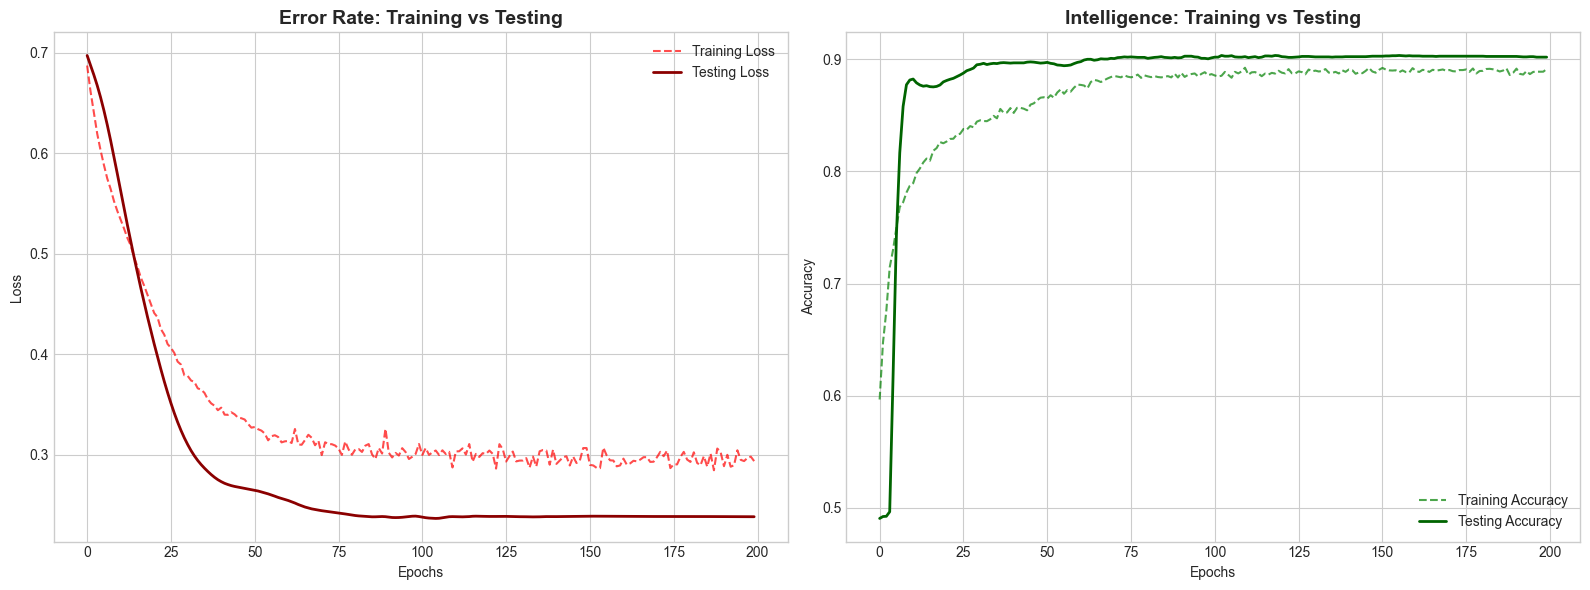

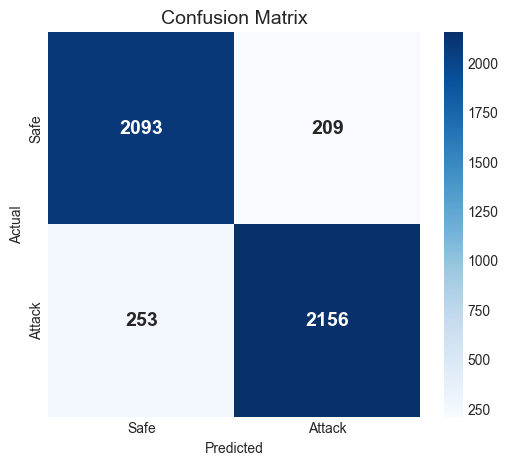

In [24]:
# Advanced Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(16, 6))

# Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history_train_loss, label='Training Loss', color='red', linestyle='--', alpha=0.7)
plt.plot(history_val_loss, label='Testing Loss', color='darkred', linewidth=2)
plt.title('Error Rate: Training vs Testing', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history_train_acc, label='Training Accuracy', color='green', linestyle='--', alpha=0.7)
plt.plot(history_val_acc, label='Testing Accuracy', color='darkgreen', linewidth=2)
plt.title('Intelligence: Training vs Testing', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Confusion Matrix
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_preds = (test_outputs > 0.5).float()

cm = confusion_matrix(y_test, test_preds.cpu())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe', 'Attack'], 
            yticklabels=['Safe', 'Attack'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [27]:
# Final Report Card (Train vs Test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model.eval()

# Check Training Accuracy
with torch.no_grad():
    train_outputs = model(X_train_tensor)
    train_preds = (train_outputs > 0.5).float()
    # y_train_tensor is a Tensor, so .cpu() is needed
    train_acc = accuracy_score(y_train_tensor.cpu(), train_preds.cpu())

# Check Testing Accuracy
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_preds = (test_outputs > 0.5).float()
    test_acc = accuracy_score(y_test, test_preds.cpu())

print(f" Training Accuracy: {train_acc*100:.2f}%")
print(f" Testing Accuracy:  {test_acc*100:.2f}%\n")

y_test_np = y_test
test_preds_np = test_preds.cpu().numpy()

precision = precision_score(y_test_np, test_preds_np)
recall = recall_score(y_test_np, test_preds_np)
f1 = f1_score(y_test_np, test_preds_np)

print(f" DNN Precision: {precision*100:.2f}%")
print(f" DNN Recall:    {recall*100:.2f}%")
print(f" DNN F1-Score:  {f1*100:.2f}%\n")

print("--- DNN Classification Report ---")
print(classification_report(y_test_np, test_preds_np, target_names=['Benign', 'Attack']))

if train_acc - test_acc > 0.05:
    print("️ Warning: Model is Overfitting (Memorizing data).")
else:
    print(" Success: Model is Generalizing well (True Intelligence).")

 Training Accuracy: 91.35%
 Testing Accuracy:  90.19%

 DNN Precision: 91.16%
 DNN Recall:    89.50%
 DNN F1-Score:  90.32%

--- DNN Classification Report ---
              precision    recall  f1-score   support

      Benign       0.89      0.91      0.90      2302
      Attack       0.91      0.89      0.90      2409

    accuracy                           0.90      4711
   macro avg       0.90      0.90      0.90      4711
weighted avg       0.90      0.90      0.90      4711

 Success: Model is Generalizing well (True Intelligence).


In [26]:
# Save Model for Production
torch.save(model.state_dict(), "../controller/models_dist/dnn_model.pth")
print(" DNN Model saved to ../controller/models_dist/dnn_model.pth")

 DNN Model saved to ../controller/models_dist/dnn_model.pth
